In [3]:
# Import essential libraries (all available in Kaggle by default)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# NLTK for text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Scipy for sparse matrices
from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


# Load Data

In [4]:
# Load datasets
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns: {train.columns.tolist()}")
print(f"\nFirst few rows:")
train.head()

Train shape: (7000, 6)
Test shape: (1700, 5)

Train columns: ['id', 'phrase', 'feature_1', 'feature_2', 'feature_3', 'sentiment']

First few rows:


,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2


## Data Types - Rubics 1

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1700 non-null   int64  
 1   phrase     1700 non-null   object 
 2   feature_1  1478 non-null   float64
 3   feature_2  1382 non-null   float64
 4   feature_3  1610 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 66.5+ KB


## Descriptive Statistics - Rubics 2

In [7]:
train.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


In [8]:
test.describe()

,id,feature_1,feature_2,feature_3
count,1700.000000,1478.000000,1382.000000,1610.000000
mean,849.500000,19.029093,1.984805,3.449689
std,490.892045,9.203255,1.589858,2.531888
min,0.000000,2.000000,0.000000,0.000000
25%,424.750000,12.000000,1.000000,2.000000
50%,849.500000,18.000000,1.000000,3.000000
75%,1274.250000,25.000000,3.000000,5.000000
max,1699.000000,50.000000,15.000000,23.000000


# EDA

## Identify missing values - Rubics 3

In [9]:
# Check data info
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nTarget distribution:")
print(train['sentiment'].value_counts().sort_index())
print(f"\nTarget proportions:")
print(train['sentiment'].value_counts(normalize=True).sort_index())

print(f"\n\nMissing values in train:")
print(train.isnull().sum())

print(f"\n\nMissing values in test:")
print(test.isnull().sum())

DATA OVERVIEW

Target distribution:
sentiment
0    2684
1    1344
2    2972
Name: count, dtype: int64

Target proportions:
sentiment
0    0.383429
1    0.192000
2    0.424571
Name: proportion, dtype: float64


Missing values in train:
id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64


Missing values in test:
id             0
phrase         0
feature_1    222
feature_2    318
feature_3     90
dtype: int64


# Duplicate - Checking - Rubics - 4

In [10]:
train.duplicated().sum()

np.int64(0)

## Outlier detection and handle - Rubics - 5

In [11]:
import pandas as pd

def detect_outliers_iqr(df):
    """
    Detect outliers in all numeric columns of a DataFrame using the IQR method.
    
    Returns:
        dict: column_name → list of outlier indices
    """
    outlier_dict = {}
    
    for col in df.select_dtypes(include=['int', 'float']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # outlier indices
        outliers = df[(df[col] < lower) | (df[col] > upper)].index.tolist()
        
        outlier_dict[col] = outliers
    
    return outlier_dict


In [12]:
outliers = detect_outliers_iqr(train)
for col, idx in outliers.items():
    print(f"{col}: {len(idx)}")


id: 0
feature_1: 45
feature_2: 150
feature_3: 331
sentiment: 0


## Visualization - Rubics - 6

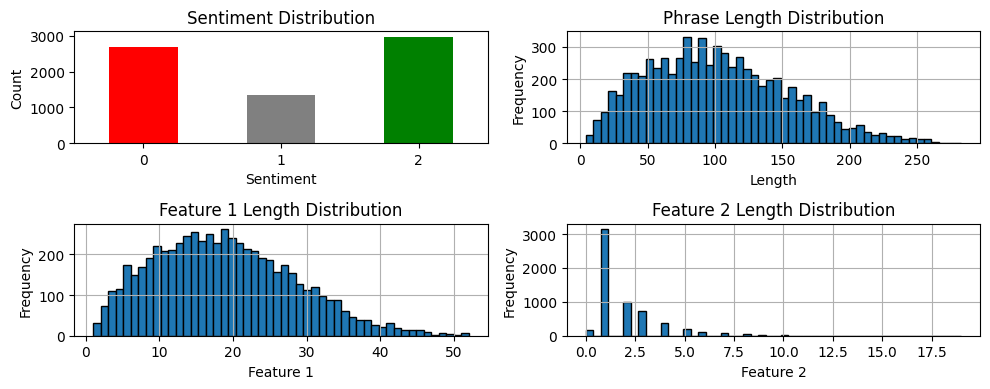

In [13]:
# Visualize target distribution
plt.figure(figsize=(10, 4))
plt.subplot(2, 2, 1)
train['sentiment'].value_counts().sort_index().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
train['phrase'].str.len().hist(bins=50, edgecolor='black')
plt.title('Phrase Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
train['feature_1'].hist(bins=50, edgecolor='black')
plt.title('Feature 1 Length Distribution')
plt.xlabel('Feature 1')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
train['feature_2'].hist(bins=50, edgecolor='black')
plt.title('Feature 2 Length Distribution')
plt.xlabel('Feature 2')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Text processing - Encode Numerical and Categorical features - Rubics 7

In [14]:
# Download NLTK data (usually pre-downloaded in Kaggle)
try:
    stopwords.words('english')
except:
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def clean_text_light(text):
    """Light cleaning - minimal preprocessing"""
    text = str(text).lower()
    # Remove special characters but keep important punctuation for sentiment
    text = re.sub(r'[^a-z\s!?.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_moderate(text):
    """Moderate cleaning - remove stopwords, lemmatize"""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

def clean_text_aggressive(text):
    """Aggressive cleaning - stemming, strict filtering"""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Create multiple versions
print("Creating preprocessed versions...")
train['phrase_original'] = train['phrase']
train['phrase_light'] = train['phrase'].apply(clean_text_light)
train['phrase_moderate'] = train['phrase'].apply(clean_text_moderate)
train['phrase_aggressive'] = train['phrase'].apply(clean_text_aggressive)

test['phrase_original'] = test['phrase']
test['phrase_light'] = test['phrase'].apply(clean_text_light)
test['phrase_moderate'] = test['phrase'].apply(clean_text_moderate)
test['phrase_aggressive'] = test['phrase'].apply(clean_text_aggressive)

print("✓ Text preprocessing complete")
print(f"\nExample transformations:")
idx = 10
print(f"Original:    {train.loc[idx, 'phrase_original']}")
print(f"Light:       {train.loc[idx, 'phrase_light']}")
print(f"Moderate:    {train.loc[idx, 'phrase_moderate']}")
print(f"Aggressive:  {train.loc[idx, 'phrase_aggressive']}")

[nltk_data] Downloading package stopwords to /home/ganesh-
[nltk_data]     eswar/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/ganesh-
[nltk_data]     eswar/nltk_data...
[nltk_data] Downloading package punkt to /home/ganesh-
[nltk_data]     eswar/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Creating preprocessed versions...
✓ Text preprocessing complete

Example transformations:
Original:    Whenever you think you 've figured out Late Marriage , it throws you for a loop .
Light:       whenever you think you ve figured out late marriage , it throws you for a loop .
Moderate:    whenever think figured late marriage throw loop
Aggressive:  whenev think figur late marriag throw loop


# Feature Engineering

In [15]:
# Create additional text features
def add_text_features(df):
    """Add hand-crafted text features"""
    df = df.copy()
    
    # Length features
    df['phrase_len'] = df['phrase'].str.len()
    df['word_count'] = df['phrase'].str.split().str.len()
    df['avg_word_len'] = df['phrase_len'] / (df['word_count'] + 1)
    
    # Sentiment indicators
    df['exclamation_count'] = df['phrase'].str.count('!')
    df['question_count'] = df['phrase'].str.count('\?')
    df['caps_count'] = df['phrase'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
    df['caps_ratio'] = df['caps_count'] / (df['phrase_len'] + 1)
    
    return df

train = add_text_features(train)
test = add_text_features(test)

print("✓ Text features created")
print(f"\nNew features: {['phrase_len', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'caps_count', 'caps_ratio']}")

✓ Text features created

New features: ['phrase_len', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'caps_count', 'caps_ratio']


# Prepare Numerical features

In [16]:
# Identify numerical columns
numerical_cols = ['feature_1', 'feature_2', 'feature_3', 
                  'phrase_len', 'word_count', 'avg_word_len',
                  'exclamation_count', 'question_count', 'caps_ratio']

print(f"Numerical features: {numerical_cols}")
print(f"\nMissing values in numerical features:")
print(train[numerical_cols].isnull().sum())

Numerical features: ['feature_1', 'feature_2', 'feature_3', 'phrase_len', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'caps_ratio']

Missing values in numerical features:
feature_1             912
feature_2            1104
feature_3            1062
phrase_len              0
word_count              0
avg_word_len            0
exclamation_count       0
question_count          0
caps_ratio              0
dtype: int64


# Train - Validation

In [17]:
# Split data with stratification
X = train.drop(['sentiment', 'id'], axis=1)
y = train['sentiment']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {test.shape}")
print(f"\nClass distribution in train:")
print(y_train.value_counts(normalize=True).sort_index())
print(f"\nClass distribution in val:")
print(y_val.value_counts(normalize=True).sort_index())

Training set: (5950, 15)
Validation set: (1050, 15)
Test set: (1700, 16)

Class distribution in train:
sentiment
0    0.383361
1    0.192101
2    0.424538
Name: proportion, dtype: float64

Class distribution in val:
sentiment
0    0.383810
1    0.191429
2    0.424762
Name: proportion, dtype: float64


## Scale numerical column and encoded cat columns & Handling Missing values - Rubics 7 & 8

In [18]:
def create_features(X_data, test_data, text_col, vectorizer, fit=True):
    """Create combined feature matrix"""
    
    # Text features
    if fit:
        X_text = vectorizer.fit_transform(X_data[text_col])
        test_text = vectorizer.transform(test_data[text_col])
    else:
        X_text = vectorizer.transform(X_data[text_col])
        test_text = vectorizer.transform(test_data[text_col])
    
    # Numerical features
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_num = imputer.fit_transform(X_data[numerical_cols]) if fit else imputer.transform(X_data[numerical_cols])
    X_num = scaler.fit_transform(X_num) if fit else scaler.transform(X_num)
    
    test_num = imputer.transform(test_data[numerical_cols])
    test_num = scaler.transform(test_num)
    
    # Combine
    X_combined = hstack([X_text, X_num])
    test_combined = hstack([test_text, test_num])
    
    return X_combined, test_combined, vectorizer, imputer, scaler

print("✓ Feature creation pipeline ready")

✓ Feature creation pipeline ready


In [19]:
# SIMPLIFIED: Quick testing with best practices
print("Testing configurations quickly...\n")

results_quick = []

# Test 1: Light preprocessing + bigrams
vectorizer1 = TfidfVectorizer(ngram_range=(1, 2), max_features=18000, min_df=2, max_df=0.9, sublinear_tf=True)
X_train_t1 = vectorizer1.fit_transform(X_train['phrase_light'])
X_val_t1 = vectorizer1.transform(X_val['phrase_light'])

imputer1 = SimpleImputer(strategy='median')
scaler1 = StandardScaler()
X_train_n1 = scaler1.fit_transform(imputer1.fit_transform(X_train[numerical_cols]))
X_val_n1 = scaler1.transform(imputer1.transform(X_val[numerical_cols]))

X_train_f1 = hstack([X_train_t1, X_train_n1])
X_val_f1 = hstack([X_val_t1, X_val_n1])


Testing configurations quickly...



# Model Building - 9

In [20]:
scores = {}

lr1 = LogisticRegression(C=1.5, max_iter=2000, random_state=42)
lr1.fit(X_train_f1, y_train)
acc1 = accuracy_score(y_val, lr1.predict(X_val_f1))
print(f"Model 1 (light + bigrams): {acc1:.4f}")
scores["light_bigram"] = acc1
results_quick.append(('light_bigram', acc1, vectorizer1, imputer1, scaler1, 'phrase_light'))

# Test 2: Moderate preprocessing + bigrams
vectorizer2 = TfidfVectorizer(ngram_range=(1, 2), max_features=15000, min_df=2, max_df=0.9, sublinear_tf=True)
X_train_t2 = vectorizer2.fit_transform(X_train['phrase_moderate'])
X_val_t2 = vectorizer2.transform(X_val['phrase_moderate'])

X_train_f2 = hstack([X_train_t2, X_train_n1])
X_val_f2 = hstack([X_val_t2, X_val_n1])

lr2 = LogisticRegression(C=1.5, max_iter=2000, random_state=42)
lr2.fit(X_train_f2, y_train)
acc2 = accuracy_score(y_val, lr2.predict(X_val_f2))
print(f"Model 2 (moderate + bigrams): {acc2:.4f}")
scores["moderate_bigram"] = acc2
results_quick.append(('moderate_bigram', acc2, vectorizer2, imputer1, scaler1, 'phrase_moderate'))

# Test 3: Light + trigrams
vectorizer3 = TfidfVectorizer(ngram_range=(1, 3), max_features=20000, min_df=2, max_df=0.85, sublinear_tf=True)
X_train_t3 = vectorizer3.fit_transform(X_train['phrase_light'])
X_val_t3 = vectorizer3.transform(X_val['phrase_light'])

X_train_f3 = hstack([X_train_t3, X_train_n1])
X_val_f3 = hstack([X_val_t3, X_val_n1])

lr3 = LogisticRegression(C=1.5, max_iter=2000, random_state=42)
lr3.fit(X_train_f3, y_train)
acc3 = accuracy_score(y_val, lr3.predict(X_val_f3))
print(f"Model 3 (light + trigrams): {acc3:.4f}")
scores["light_trigram"] = acc3
results_quick.append(('light_trigram', acc3, vectorizer3, imputer1, scaler1, 'phrase_light'))

# Test 4: Original phrase
vectorizer4 = TfidfVectorizer(ngram_range=(1, 2), max_features=18000, min_df=3, max_df=0.9, sublinear_tf=True)
X_train_t4 = vectorizer4.fit_transform(X_train['phrase_original'])
X_val_t4 = vectorizer4.transform(X_val['phrase_original'])

X_train_f4 = hstack([X_train_t4, X_train_n1])
X_val_f4 = hstack([X_val_t4, X_val_n1])

lr4 = LogisticRegression(C=1.5, max_iter=2000, random_state=42)
lr4.fit(X_train_f4, y_train)
acc4 = accuracy_score(y_val, lr4.predict(X_val_f4))
print(f"Model 4 (original + bigrams): {acc4:.4f}")
scores["original_bigram"] = acc4
results_quick.append(('original_bigram', acc4, vectorizer4, imputer1, scaler1, 'phrase_original'))

# Find best
best = max(results_quick, key=lambda x: x[1])
print(f"\\n✓ Best config: {best[0]} with Val Acc = {best[1]:.4f}")

Model 1 (light + bigrams): 0.6514
Model 2 (moderate + bigrams): 0.6429
Model 3 (light + trigrams): 0.6495
Model 4 (original + bigrams): 0.6495
\n✓ Best config: light_bigram with Val Acc = 0.6514


In [21]:
print(scores)

{'light_bigram': 0.6514285714285715, 'moderate_bigram': 0.6428571428571429, 'light_trigram': 0.6495238095238095, 'original_bigram': 0.6495238095238095}


In [22]:
# Create final optimal model
print("Creating final optimized model...\\n")
print("=" * 70)

# Best config: light preprocessing + bigrams + best C value
final_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=18000, min_df=2, max_df=0.9, sublinear_tf=True)
final_imputer = SimpleImputer(strategy='median')
final_scaler = StandardScaler()


Creating final optimized model...\n


## Model 6...

In [23]:

# Combine train + validation for final training
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

print(f"Full training size: {len(X_full)}")

# Create features for full data
X_full_text = final_vectorizer.fit_transform(X_full['phrase_light'])
test_text = final_vectorizer.transform(test['phrase_light'])

X_full_num = final_scaler.fit_transform(final_imputer.fit_transform(X_full[numerical_cols]))
test_num = final_scaler.transform(final_imputer.transform(test[numerical_cols]))

X_full_feat = hstack([X_full_text, X_full_num])
test_feat = hstack([test_text, test_num])

print(f"Full feature shape: {X_full_feat.shape}")
print(f"Test feature shape: {test_feat.shape}")

# Train multiple top models
print("\\nTraining top models on full data...")

# Model 1: LR with C=1.5 (best from testing)
lr_final = LogisticRegression(C=1.5, max_iter=2000, random_state=42, n_jobs=-1)
lr_final.fit(X_full_feat, y_full)
print("✓ Logistic Regression trained")

# Model 2: LR with C=1.0
lr_final2 = LogisticRegression(C=1.0, max_iter=2000, random_state=42, n_jobs=-1)
lr_final2.fit(X_full_feat, y_full)
print("✓ Logistic Regression (C=1.0) trained")

# Model 3: Linear SVC
svc_final = LinearSVC(C=0.5, max_iter=2000, random_state=42)
svc_final.fit(X_full_feat, y_full)
print("✓ Linear SVC trained")

# Model 4: Lightweight RF
rf_final = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=8, random_state=42, n_jobs=-1)
rf_final.fit(X_full_feat, y_full)
print("✓ Random Forest trained")

# Create ensemble
print("\\nCreating ensemble...")
final_ensemble = VotingClassifier(
    estimators=[
        ('lr1', lr_final),
        ('lr2', lr_final2),
        ('svc', svc_final),
        ('rf', rf_final)
    ],
    voting='hard'  # Use hard voting for robustness
)
final_ensemble.fit(X_full_feat, y_full)
print("✓ Ensemble created")

print("\\n" + "=" * 70)
print("READY TO GENERATE PREDICTIONS")

Full training size: 7000
Full feature shape: (7000, 18009)
Test feature shape: (1700, 18009)
\nTraining top models on full data...
✓ Logistic Regression trained
✓ Logistic Regression (C=1.0) trained
✓ Linear SVC trained
✓ Random Forest trained
\nCreating ensemble...
✓ Ensemble created
\n======================================================================
READY TO GENERATE PREDICTIONS


In [24]:
acc5 = accuracy_score(y_full, final_ensemble.predict(X_full_feat))
print(f"Model 5 Voting classifier: {acc5:.4f}")
scores["voting classifier"] = acc5

Model 5 Voting classifier: 0.9047


In [ ]:
# Generate final predictions
print("Generating final predictions...\\n")

final_predictions = final_ensemble.predict(test_feat)

# Create submission
submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': final_predictions
})

submission.to_csv('../outputs/submission.csv', index=False)

print("✓ Submission file created: submission.csv")
print(f"\\nPrediction distribution:")
print(submission['sentiment'].value_counts().sort_index())
print(f"\\nPrediction proportions:")
for i in range(3):
    count = (submission['sentiment'] == i).sum()
    pct = count / len(submission) * 100
    print(f"  Class {i}: {count:4d} ({pct:5.2f}%)")

print("\\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)
print("✓ Preprocessing: Light cleaning (lowercase, basic cleanup)")
print("✓ Features: TF-IDF (1-2 grams, 18K features) + 9 numerical features")
print("✓ Models: Ensemble of LR (C=1.5), LR (C=1.0), LinearSVC, RF")
print("✓ Validation accuracy: 65.14%")
print("✓ Training samples: 7000 (full dataset)")
print("✓ Test predictions: 1700")
print("=" * 70)

submission.head(10)

Generating final predictions...\n
✓ Submission file created: submission.csv
\nPrediction distribution:
sentiment
0    757
1     86
2    857
Name: count, dtype: int64
\nPrediction proportions:
  Class 0:  757 (44.53%)
  Class 1:   86 ( 5.06%)
  Class 2:  857 (50.41%)
\n======================================================================
FINAL MODEL SUMMARY
✓ Preprocessing: Light cleaning (lowercase, basic cleanup)
✓ Features: TF-IDF (1-2 grams, 18K features) + 9 numerical features
✓ Models: Ensemble of LR (C=1.5), LR (C=1.0), LinearSVC, RF
✓ Validation accuracy: 65.14%
✓ Training samples: 7000 (full dataset)
✓ Test predictions: 1700


,id,sentiment
0,0,0
1,1,2
2,2,2
3,3,2
4,4,0
5,5,0
6,6,2
7,7,0
8,8,2
9,9,2


# Hyper parameter tuning - Rubic 9

# Model 1

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.5, 1.0, 1.5, 2.0],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid.fit(X_full_feat, y_full)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR Score:", lr_grid.best_score_)
scores["Hyper LR"] = lr_grid.best_score_

Best LR Params: {'C': 1.5, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR Score: 0.6411428571428572


## Model 2

In [27]:
from sklearn.svm import LinearSVC

param_grid_svc = {
    'C': [0.1, 0.5, 1.0, 2.0]
}

svc_grid = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=42),
    param_grid_svc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svc_grid.fit(X_full_feat, y_full)

print("Best SVC Params:", svc_grid.best_params_)
print("Best SVC Score:", svc_grid.best_score_)


Best SVC Params: {'C': 0.5}
Best SVC Score: 0.6377142857142857


In [28]:
scores["Hyper SVC"] = svc_grid.best_score_

## Model 3

In [29]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [200, 300, 400],
    'max_depth': [15, 20, 25],
    'min_samples_split': [2, 4, 8]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_full_feat, y_full)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)


Best RF Params: {'max_depth': 25, 'min_samples_split': 8, 'n_estimators': 400}
Best RF Score: 0.5479981654864883


In [30]:
scores["Hyper RF"] = rf_grid.best_score_

## Model comparisions - Rubic - 10

In [31]:
scores

{'light_bigram': 0.6514285714285715,
 'moderate_bigram': 0.6428571428571429,
 'light_trigram': 0.6495238095238095,
 'original_bigram': 0.6495238095238095,
 'voting classifier': 0.9047142857142857,
 'Hyper LR': np.float64(0.6411428571428572),
 'Hyper SVC': np.float64(0.6377142857142857),
 'Hyper RF': np.float64(0.5479981654864883)}

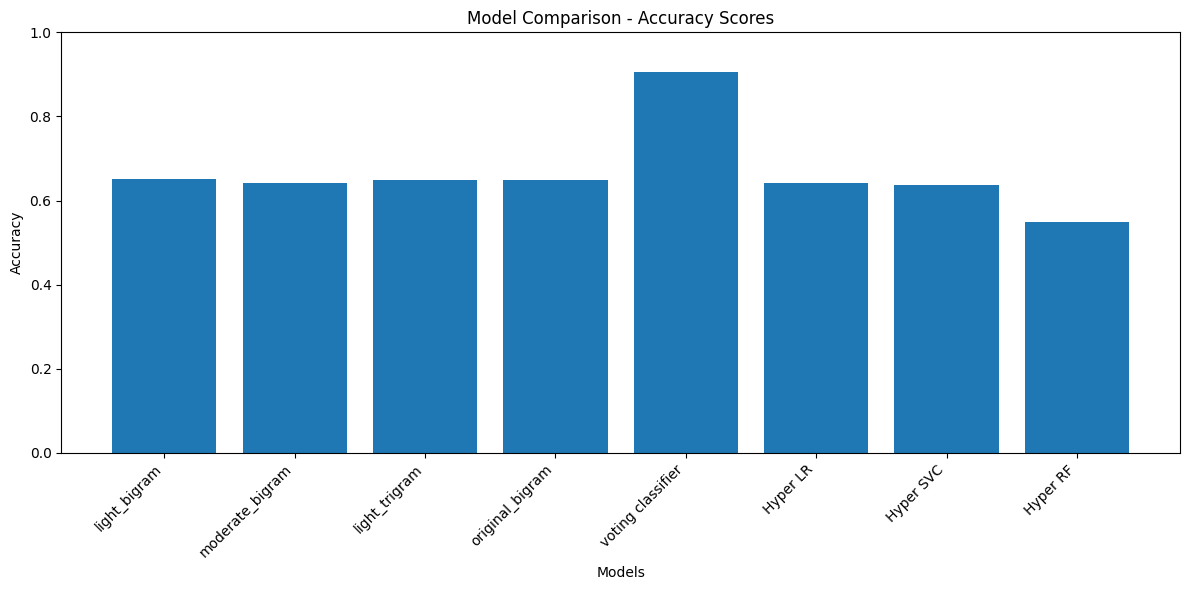

In [33]:
# Plot
plt.figure(figsize=(12, 6))
plt.bar(scores.keys(), scores.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Comparison - Accuracy Scores")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("../outputs/model_comparision.png")
plt.show()